<a href="https://colab.research.google.com/github/ftycity23/DSRP-Research-Project/blob/main/DSRP_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[ The Emmy Awards: Nominees and Winners](https://docs.google.com/document/d/1V9qcy1RQN6Suq3_3X_aQ6k6-pyZSjupPF7CYYVqXZ1g/edit?tab=t.0)**

**File upload of the data** - Emmy Awards Data


**Description of data**: This dataset describes the evolution of the television industry by highlighting key trends and changes over time. TidyTuesday released it as part of an open data project in September 2021. You can also extract the data directly from the Emmy website, where it spans a longer time from 1957 to 2021. The cleaned version of the dataset consists of approximately 30,000 rows and 7 columns, with each row representing one nomination or win, depending on the “type” indicated. The variables included are category, production, type, title, distributor, producer, and year.



Since the first Emmy ceremony in 1949, the television landscape has evolved dramatically, through black-and-white broadcasts, 1950s color TV, 1960s cable expansion, and today’s dominant streaming platforms1. Throughout all these eras, the Emmy Awards, the annual television honors which recognize excellence across categories such as comedy, acting, writing, and technical achievement, have remained the preeminent awards show for the genre.
Among the three organizations overseeing the awards is the Television Academy. The Television Academy has more than 26,000 members, each belonging to one of 31 peer groups representing specific fields such as acting, directing, and writing. For nominations, all active members can vote in program categories, and peer groups vote within their categories of expertise. Before voting begins, contenders must be submitted to appear on the ballot in a specific category, and aspiring nominees must submit an episode of their best work. After nominations are announced, voters are expected to watch episode submissions on the TV Academy’s streaming platform before casting final votes, deciding on one winner per category, such as “Most Outstanding” Awards for Drama, Comedy, Directing, and Writing.
This Emmy nominations dataset reflects the evolution of the television industry by highlighting shifting trends and tastes in television.



## *From Networks to Streaming: What Predicts Emmy Recognition?*

## **Research Question:** Which combinations of distributor, category, and era predict the highest Emmy win rates, and has that recognition shifted from broadcast networks toward streaming platforms over time?

In [1]:
!git clone https://github.com/ftycity23/DSRP-Research-Project.git


import pandas as pd
df = pd.read_csv("DSRP-Research-Project/emmys_original.csv")
df.head()

fatal: destination path 'DSRP-Research-Project' already exists and is not an empty directory.


,category,logo,production,type,title,distributor,producer,year,page,page_id
0,Outstanding Character Voice-Over Performance -...,https://www.emmys.com/sites/default/files/styl...,NaN,Nominee,black-ish: Election Special (Part 2),ABC,ABC,2021,0,1
1,Outstanding Character Voice-Over Performance -...,https://www.emmys.com/sites/default/files/styl...,NaN,Nominee,Bridgerton,Netflix,A Netflix Original Series in association with ...,2021,0,2
2,Outstanding Character Voice-Over Performance -...,https://www.emmys.com/sites/default/files/styl...,NaN,Nominee,Family Guy,FOX,20th Television Animation,2021,0,3
3,Outstanding Character Voice-Over Performance -...,https://www.emmys.com/sites/default/files/styl...,NaN,Nominee,Archer,FX Networks,FX Productions,2021,0,4
4,Outstanding Production Design For A Narrative ...,https://www.emmys.com/sites/default/files/styl...,"Elisabeth Williams, Production Designer",Nominee,The Handmaid's Tale,Hulu,"Hulu, MGM, Daniel Wilson Productions, The Litt...",2021,0,5


Importing pandas & matplotlib for set up

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Exploring the data itself with pandas by creating a DataFrame

Exploring the average year, median year, and how many Nominees vs. Winners

In [3]:
df['type'].value_counts()

,count
type,
Nominee,23739
Winner,5939


In [4]:
df['year'].mean()

np.float64(2013.6110250016848)

Figuring out the actual year

In [5]:
avgactual_year = int(df['year'].mean())

In [6]:
print(f"The average actual year is {avgactual_year}")

The average actual year is 2013


In [7]:
df['year'].median()

2015.0

# Analyzing the data and inspecting info

Looking at head and info of the data

In [8]:
df.head()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29678 entries, 0 to 29677
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     29678 non-null  object
 1   logo         29678 non-null  object
 2   production   26825 non-null  object
 3   type         29678 non-null  object
 4   title        29678 non-null  object
 5   distributor  29675 non-null  object
 6   producer     29678 non-null  object
 7   year         29678 non-null  int64 
 8   page         29678 non-null  int64 
 9   page_id      29678 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 2.3+ MB


In [9]:
df.isna().sum()

,0
category,0
logo,0
production,2853
type,0
title,0
distributor,3
producer,0
year,0
page,0
page_id,0


# Capturing the number of rows, columns, and the last 5 rows of the dataset.


`df.tail() and df.shape`




In [10]:
df.tail()

,category,logo,production,type,title,distributor,producer,year,page,page_id
29673,BEST CONTINUING PERFORMANCE BY AN ACTRESS - 1957,/sites/all/themes/emmys/img/winners_outsanding...,NaN,Nominee,Jane Wyman Theatre,NBC,NBC,1957,2281,6
29674,BEST CONTINUING PERFORMANCE BY AN ACTRESS - 1957,https://www.emmys.com/sites/default/files/styl...,NaN,Winner,The Loretta Young Show,NBC,NBC,1957,2281,7
29675,BEST CONTINUING PERFORMANCE BY AN ACTRESS - 1957,/sites/all/themes/emmys/img/winners_outsanding...,NaN,Nominee,Lassie,CBS,CBS,1957,2281,8
29676,BEST CONTINUING PERFORMANCE BY AN ACTRESS - 1957,/sites/all/themes/emmys/img/winners_outsanding...,NaN,Nominee,Four Star Playhouse,CBS,CBS,1957,2281,9
29677,BEST CONTINUING PERFORMANCE BY AN ACTRESS - 1957,/sites/all/themes/emmys/img/winners_outsanding...,NaN,Nominee,Mama,CBS,CBS,1957,2281,10


In [11]:
df.shape

(29678, 10)

# Extracting the columns values

Putting them into the variable cols

In [12]:
cols = ['category','production','type','title','distributor','producer','year']

# Checking for missing values within the dataset (insull)

Using
```isnull().sum()```
to figure and count how many rows are missing a specific value within a column



In [13]:
df.isnull().sum()

,0
category,0
logo,0
production,2853
type,0
title,0
distributor,3
producer,0
year,0
page,0
page_id,0


**Missing the 2853 production columns and 3 distributor columns!!!**

# **Cleaning Data**

## Checking for duplicates and inconsistency in data

#### Counting the rows of exact copies from an earlier row

In [14]:
df.duplicated().sum()

np.int64(0)

## **Cleaning and dropping the rows that are missing**

Creating a df_clean variable to pull all the data from the function in here

In [15]:
df_clean = df.drop(columns=['logo', 'page', 'page_id'])

**Counting the current size of the clean data after dropping the columns initially.**

> Add blockquote



## Removing the rows where the distributor comn as now value/ empty value and saves the result within df_clean

In [16]:
df_clean = df_clean.dropna(subset=['distributor'])

In [17]:
df_clean.shape

(29675, 7)

How many unique category values appear

In [18]:
df['category'].value_counts(dropna=False)

,count
category,
"Outstanding Technical Direction, Camerawork, Video For A Miniseries, Movie Or A Special - 2007",117
"Outstanding Technical Direction, Camerawork, Video For A Miniseries, Movie Or A Special - 2008",111
Outstanding Drama Series - 2021,109
Outstanding Animated Program - 2019,102
"Outstanding Technical Direction, Camerawork, Video Control For A Miniseries, Movie Or A Special - 2013",101
...,...
Television Academy Honors - 2012,1
Outstanding Lead Actress In A Drama Series - 2010,1
"Outstanding Costumes For A Variety, Music Program Or A Special - 2009",1


Truncating the years at the end of each category value to just include the name

In [19]:
df_clean['category'] = df_clean['category'].str.replace(r'\s*-\s*\d{4}$', '', regex=True)

In [20]:
df_clean['category'].nunique()

507

Checking the rows that are identical to other rows from the variable 'cols'

In [21]:
df_clean.duplicated(subset=cols).sum()

np.int64(321)

# Creating the visualizaiton(s) for data

##
```
 1. Nominees vs Winners - Single Variable
```



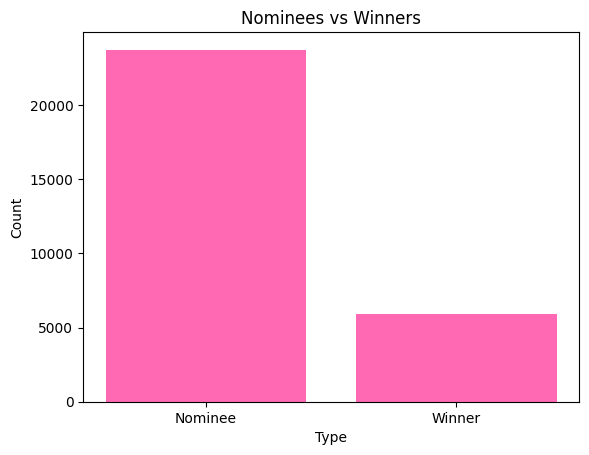

In [22]:
counts = df_clean['type'].value_counts()
plt.bar(counts.index, counts.values, color='hotpink')

plt.title ('Nominees vs Winners')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

There are more nominees because more people apply and are nominated than actually win, which is expected.

##
```
 2. Nominations per year (trend, single variable)
```


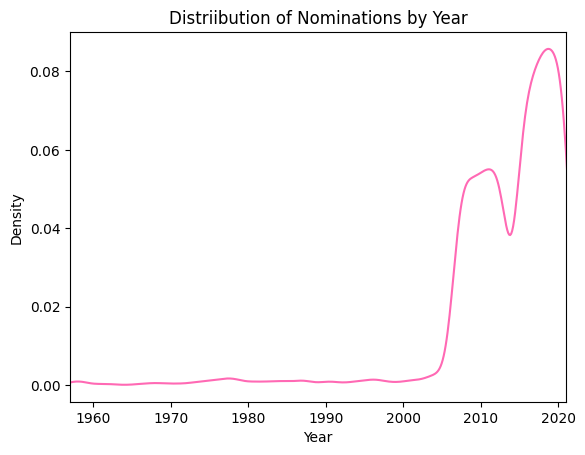

In [23]:
df_clean['year'].plot(kind='density', color='hotpink')

plt.title('Distriibution of Nominations by Year')
plt.xlabel('Year')
plt.xlim(df_clean['year'].min(), df_clean['year'].max())

plt.show()

This data is not symmetric; instead, it is right-skewed in the earlier years (2000s–2020).

### 3. Top 10 distributors by nomination count

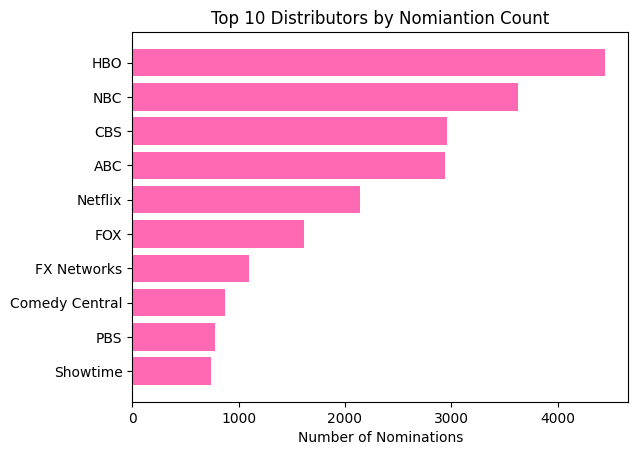

In [24]:
top_d = df_clean['distributor'].value_counts().head(10)

plt.barh(top_d.index, top_d.values, color='hotpink')
plt.title('Top 10 Distributors by Nomiantion Count')

plt.xlabel('Number of Nominations')
plt.gca().invert_yaxis()

plt.show()




HBo has the most nomnations than the other distibutors

### 4. Multiple Variables - Win rate by top distributors

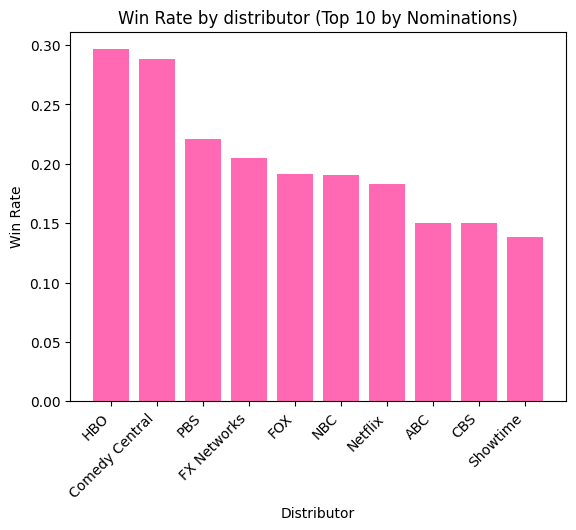

In [25]:
top10 = df_clean['distributor'].value_counts().head(10).index
filtered = df_clean[df_clean['distributor'].isin(top10)]
win_rate = (filtered['type'] == 'Winner').groupby(filtered['distributor']).mean()
win_rate = win_rate.sort_values(ascending=False)

plt.bar(win_rate.index, win_rate.values, color='hotpink' )

plt.title('Win Rate by distributor (Top 10 by Nominations)')

plt.xlabel('Distributor')
plt.ylabel('Win Rate')

plt.xticks(rotation=45, ha='right')

plt.show()

**Since HBO has the most nominations (4000+) could this potentinally be the reason it has the hihest win rate around the 30%? **Is this a coincidence?

###  5. Top nominations and top 5 distributors over time.

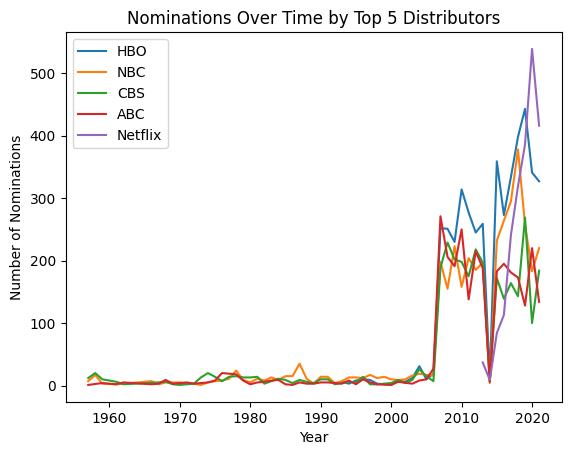

In [26]:
top5 = df_clean['distributor'].value_counts().head(5).index

for d in top5:
  subset = df_clean[df_clean['distributor'] == d]
  yearly = subset.groupby('year').size()
  plt.plot(yearly.index, yearly.values, label=d)

plt.title('Nominations Over Time by Top 5 Distributors')
plt.xlabel('Year')
plt.ylabel('Number of Nominations')
plt.legend()

plt.show()

## Checkpoint 2: **EDA Summary**

**Q1: hat have you learned from EDA so far?**


*   Cleaned dataset consists of 29,675 nominations.
*   The winningins of the Emmy Awards span around 1957-2021 across 507 distinc category awards
*   Data has one winner per year but typically 4-6 nominees for each category
*   HBO, NBC, CBS and ABC lead at the top for having the most nomineeses containing. Netflix starts to lead tin the top 5 a bit after the 2010's
*   Because of the later years, the data skews toward sthe right which makes sense because the awards became more popular in the recent years








**Q2: Are there any interesting relationships between variables? Which variables show the most variation?**



* Distributor and win rate appear to be related.
* Some distributors convert nominations into wins more often than others.
* Distributor trends also shift over time; streaming platforms like Netflix rise sharply after 2013, while others stay relatively steady, which may help show which networks win more.
* Category has the most variation, with 507 distinct values.


Distributor Bar Chart

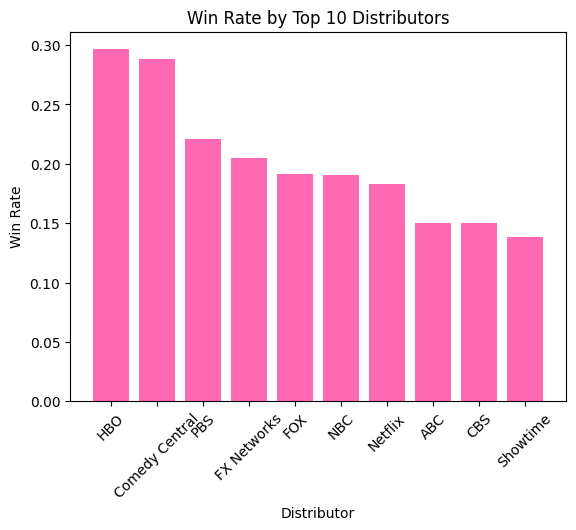

In [27]:
top10 = df_clean['distributor'].value_counts().head(10).index
subset = df_clean[df_clean['distributor'].isin(top10)]
win_rate = (subset['type'] == 'Winner').groupby(subset['distributor']).mean().sort_values(ascending=False)

plt.bar(win_rate.index, win_rate.values, color='hotpink')
plt.xlabel('Distributor')
plt.ylabel('Win Rate')
plt.title('Win Rate by Top 10 Distributors')
plt.xticks(rotation=45)
plt.show()

**Q3: Any potential issues/unusual values?**

*  The production column is missing
in 2,853 rows — about 9.6% of the dataset.

*  Because so much of this column is missing, it limits the analysis of nominees.

*  I also found about 321 rows that looked like duplicates, but they turned out to be distinct nominees after cleaning.

*  These distinct nominees were not labeled in the original data.





## Checkpoint 3: **Satistical Analysis**

## Adding two new columns: **decade** and **won**.


*   Put the "Year" category in the 10 year groups with pd.cut() to compare streaming and broadcasting over time. (Eras hence the 10 years) and not by individual years. (Grouped into 1980's, 1990's, and 2000's, etc).

* Added the won column to differentiaite between Nominee and Winner (they need numbers rather than pure text for logiistic regression). Converting the row to won for (1) and 0 for not winining. Categorizing them into if "yes" if they won and "no" if they lost



In [28]:
bins = range(1950, 2030, 10)

labels = [f"{b}s" for b in bins[:-1]]

df_clean['decade'] = pd.cut(df_clean['year'], bins=bins, labels=labels, right=False)
df_clean['won'] = (df_clean['type'] == 'Winner')

## **Hypothesis testing:** Test 1 & 2: Chi-Squared Tests

I need to import the tools needed to split the data, measure model performance, and build the model itself.

In [29]:
from sklearn import model_selection, metrics
from sklearn.linear_model import LogisticRegression
import scipy.stats as stats

In [30]:
# Looking at the top 10 distributors, so smaller ones with few nominations don't mix the test
top10 = df_clean['distributor'].value_counts().head(10).index

subset = df_clean[df_clean['distributor'].isin(top10)]

# Building a table that counts the win/losses each disributor has
con_table = pd.crosstab(subset['distributor'], subset['type'])

print(con_table)

# Running the chi-squared test
result = stats.chi2_contingency(con_table)

print("p-value:", result.pvalue)

con_table2 = pd.crosstab(subset['decade'], subset['type'])
result2 = stats.chi2_contingency(con_table2)

print("p-value:", result2.pvalue)

type            Nominee  Winner
distributor                    
ABC                2502     443
CBS                2519     444
Comedy Central      624     253
FOX                1308     309
FX Networks         873     225
HBO                3125    1317
NBC                2933     690
Netflix            1751     393
PBS                 606     172
Showtime            640     103
p-value: 1.5559302564964703e-82
p-value: 0.07897460032652108




*   This tests whether distirbutor and winnign are related. It also examnines the data seperalting from whether decade an winning are relating. Theese variables are categories not raw numbers
*   This uses a Chi-Squared test. because it compares two categorical variables





### Building Logistic Regression model

In [31]:
model_df = df_clean[df_clean['distributor'].isin(top10)].copy()

# Spliting the data into wins and losses

won_rows = model_df[model_df['won'] == True]
lost_rows = model_df[model_df['won'] == False]

lost_rows_balanced = lost_rows.head(len(won_rows))

# Combining the two groups
balanced_df = pd.concat([won_rows, lost_rows_balanced])

X = pd.get_dummies(balanced_df[['distributor', 'decade']], drop_first=True)

y = balanced_df['won']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy Score is: ", metrics.accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

Accuracy Score is:  0.7528735632183908
              precision    recall  f1-score   support

       False       0.80      0.69      0.74       886
        True       0.72      0.82      0.76       854

    accuracy                           0.75      1740
   macro avg       0.76      0.75      0.75      1740
weighted avg       0.76      0.75      0.75      1740



In [36]:
print("Accuracy Score is: ", metrics.accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

Accuracy Score is:  0.7528735632183908
              precision    recall  f1-score   support

       False       0.80      0.69      0.74       886
        True       0.72      0.82      0.76       854

    accuracy                           0.75      1740
   macro avg       0.76      0.75      0.75      1740
weighted avg       0.76      0.75      0.75      1740



- The model achieved **75.3% accuracy**, meaning it correctly predicted the outcome in most cases.

- For the **winning class**, the model had **72% precision**, which means when it predicted a win, it was correct 72% of the time.

- The model had **82% recall** for actual wins, meaning it identified most of the real winning cases.

- The **F1 score** combines precision and recall, giving a more balanced view of the model’s performance.


*  I decided to use logistic regression
Instead of linear regression because I'm predicting a category rather than pure numbers.

*  I also converted the distributor and decade columns into 0-1 columns with pd.get_dummies().

* After that, I split the data into an 80/20 training and testing set so I could check the model’s accuracy on the data."




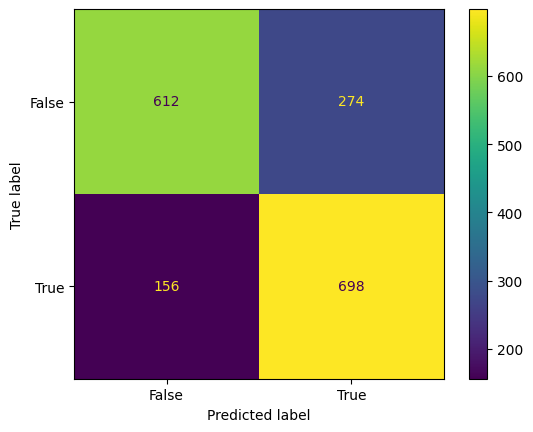

In [32]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

## **Visual** for answering Question: ## Which Features Predict Winning?

*  I decided to extract the coefficients from the logistic regression model to identify which distributor and decade combinations were most associated with winning.

In [33]:
# Extracting the model's coefficients and matching them to their column names

In [34]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()

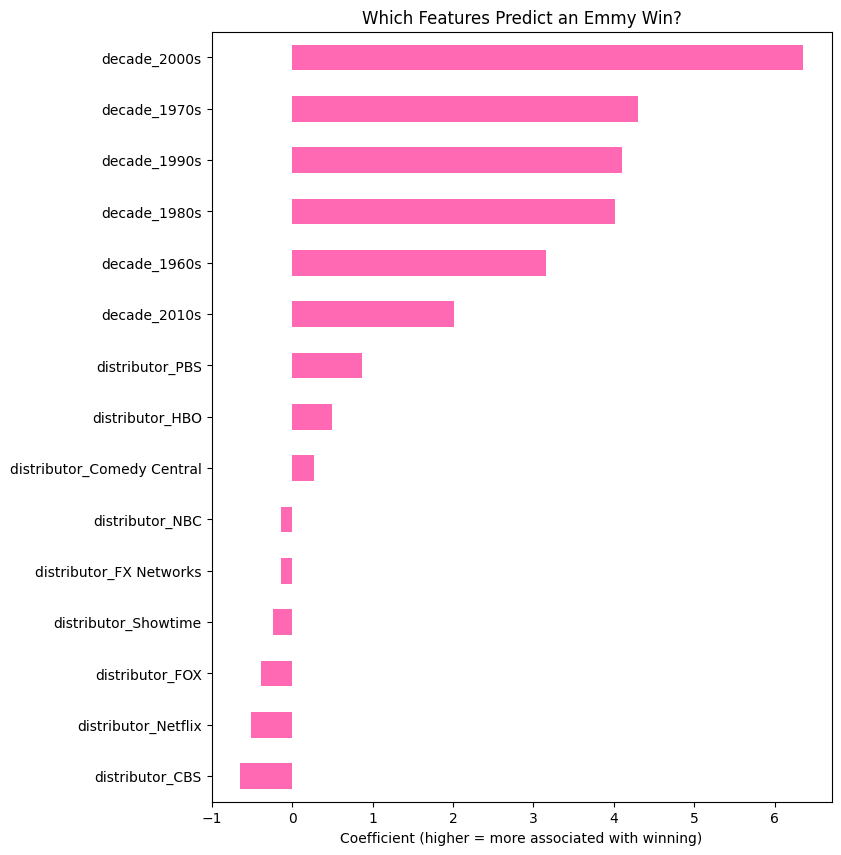

In [35]:
# Plotting them as a horizontal bar chart (Higher bar means more associated with winning,
# lower  means less association with winning)

coefs.plot(kind='barh', figsize=(8,10), color='hotpink')


plt.title('Which Features Predict an Emmy Win?')
plt.xlabel('Coefficient (higher = more associated with winning)')
plt.show()